<a href="https://colab.research.google.com/github/Rastafarian99T/Applied-Computational-Thinking-with-Python/blob/master/Copy_of_MITx_SC4x_%7C_Week_10_Case_Study_Template.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Created by:  
[**Kellen Betts**](https://www.linkedin.com/in/kellenbetts/)  
*Massachusetts Institute of Technology*
  
Course:  
[Supply Chain Technology and Systems (SC4x)](https://www.edx.org/learn/supply-chain-management/massachusetts-institute-of-technology-supply-chain-technology-and-systems)  
[MITx MicroMasters Program in Supply Chain Management](https://micromasters.mit.edu/scm/)  


# MITx SC4x | Week 10 Case Study

# Start Here

## Introduction

1. SAVE: Save of copy of this notebook to your Google Drive.

2. SUPPLEMENTAL: The contents of this notebook are an optional part of the SC4x_2T2025 course. The topics won't be included in graded assignments or exams.

3. GOALS:

  *   Show how the SQL database used in SC4x works.
  *   Show how we can connect the SQL database to other Python tools for data manipulation, analysis, plotting, and machine learning.
  *   Inspire further exploration of the many tools available with Python.

4. NAVIGATION: Use the show/hide arrow to reveal the content within each section and subsection in this notebook. All sections are collapsed initially to make navigation easier. You can also use the Table of Contents sidebar on the left to move between sections.



## Install and load packages

In [ ]:
!pip install scx>=1.2.1 # Install the 'scx' package.

Notes:

* `scx` is a custom Python package for the MITx SCx courses. It was created by by Connor Makowski on the MicroMasters team.  

*   The source code, examples, templates, and documentation for the `scx` package can be found [here on GitHub](https://github.com/connor-makowski/scx).



In [ ]:
# We'll use the Database class from the scx package for our SQL database
from scx.database import Database

# numpy is for arrays, mathematical functions, and numerical computing in Python
import numpy as np

# pandas is for data manipulation and visualization
import pandas as pd

# matplotlib is for plotting, Pandas uses matplotlib
import matplotlib.pyplot as plt

# scikit-learn is for machine learning, built on NumPy, SciPy, and matplotlib
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder

# Other packages
from pprint import pprint

---
# Part 1: Business Context and Project Overview

## Company background

BuyMore is an online marketplace that connects sellers and buyers for a wide variety of merchandise, including electronics, home goods, clothing and linen, health and beauty, and other products. Founded in 2005, BuyMore has over 3,000 sellers and a growing e-commerce business.

Merchants sell their products through the BuyMore marketplace and ship them directly to customers using BuyMore's logistics partners. After a customer purchases a product from the BuyMore platform, a seller gets notified to fulfill that order. Similar to other online marketplaces and retailers, customers write reviews and ratings for their purchase experience and products.

Recently, on-time delivery for purchases made through BuyMore has been decreasing, putting significant pressure on the company's leadership team. Sarah Chen, BuyMore's Chief Operations Officer, has been particularly concerned about this decline, noting that late deliveries have increased by 15% over the past six months. "Our customers expect Amazon-level delivery performance," Sarah observed. "If we can't deliver on time consistently, we'll lose market share to our competitors."

Michael Rodriguez, Director of Data Engineering, believes the solution lies in leveraging BuyMore's rich operational data more strategically. "We have comprehensive data across our entire fulfillment ecosystem, but we're not using it predictively," Michael explained to the executive team. "I recommend we build a new analytics database and develop machine learning models that can predict delivery delays before they happen, allowing us to proactively intervene and optimize our fulfillment processes."

## Technology Infrastructure

BuyMore's operations are supported by an integrated technology stack centered around their core business systems:

* SAP ERP System: The company's primary enterprise resource planning system manages comprehensive data about customers, sellers, and products. This includes detailed customer profiles with geographic information, seller locations and performance metrics, and complete product catalogs with specifications, categories, and inventory details.

* Order Management System (OMS): Built on Salesforce Commerce Cloud, this system handles the complete order lifecycle from placement through delivery. It captures detailed transaction records, manages order status updates, tracks delivery timelines, and coordinates between customers, sellers, and logistics partners.

## Business Challenge

Recently, on-time delivery for purchases made through BuyMore has been decreasing, putting significant pressure on the company's leadership team. Sarah Chen has expressed growing frustration with the reactive nature of their current approach: "Every Monday morning, we're analyzing what went wrong the previous week instead of preventing problems before they occur. Our customer satisfaction scores are directly correlated with delivery performance, and we're losing ground to competitors who can deliver more predictably." She has tasked the company's leaders with identifying strategies to increase on-time delivery while maintaining or preferably reducing shipping costs for sellers.

## Proposed Solution

Michael's team proposes developing a machine learning model that can predict whether an order item will be delivered on time or late based on key operational characteristics:

#### Geographic and Logistics Factors

* Cross-state shipping complexity: Whether customer and seller are located in different states, which typically increases delivery time and complexity
* Order fulfillment timing: Month of year to capture seasonal variations in logistics capacity and demand
Weekly demand patterns: Day of the week when orders are placed, affecting processing times and carrier availability

#### Product and Order Characteristics

* Product category demand: Category-specific fulfillment patterns based on product type (electronics, clothing, home goods, etc.)
* Product physical profile: Length, height, width, and weight to assess shipping complexity
* Order value and composition: Individual item quantity, pricing, and associated freight costs that influence shipping method selection

## Expected Business Impact

This predictive capability would enable BuyMore to:

* Identify at-risk orders within hours of placement rather than days later
* Provide sellers with data-driven recommendations for improving performance
* Enhance customer communication with accurate delivery predictions
* Optimize shipping method selection and routing decisions

## Project Scope

You have been asked to help BuyMore implement this vision by creating the new analytics dataset and developing the machine learning model. The project will leverage data from BuyMore's Order Management and ERP Systems, to build a predictive model that can transform the company's approach to order fulfillment from reactive to proactive.

## Data Architecture

Michael's team has identified five key data sources that capture the order fulfillment process and other characteristics you will need for this project, including:

* **Orders**: Order records including purchase timestamps, delivery dates (estimated, carrier-provided, and actual customer delivery), order status, and delivery performance indicators
* **OrderItems**: Individual line items linking orders to specific products and sellers, including quantities, pricing, freight costs, and shipping constraints
* **Products**: Product information including categories, physical specifications (weight, dimensions), and descriptive attributes
* **Customers**: Customer profiles with geographic location data and order history
* **Sellers**: Merchant details including geographic location and fulfillment capabilities

Currently, this data is located in the OMS and ERP, but Michael's team has exported each table to a CSV file. They have also sketched the relationship between the difference tables in the Entity Relationship Diagram (ERD) shown below.

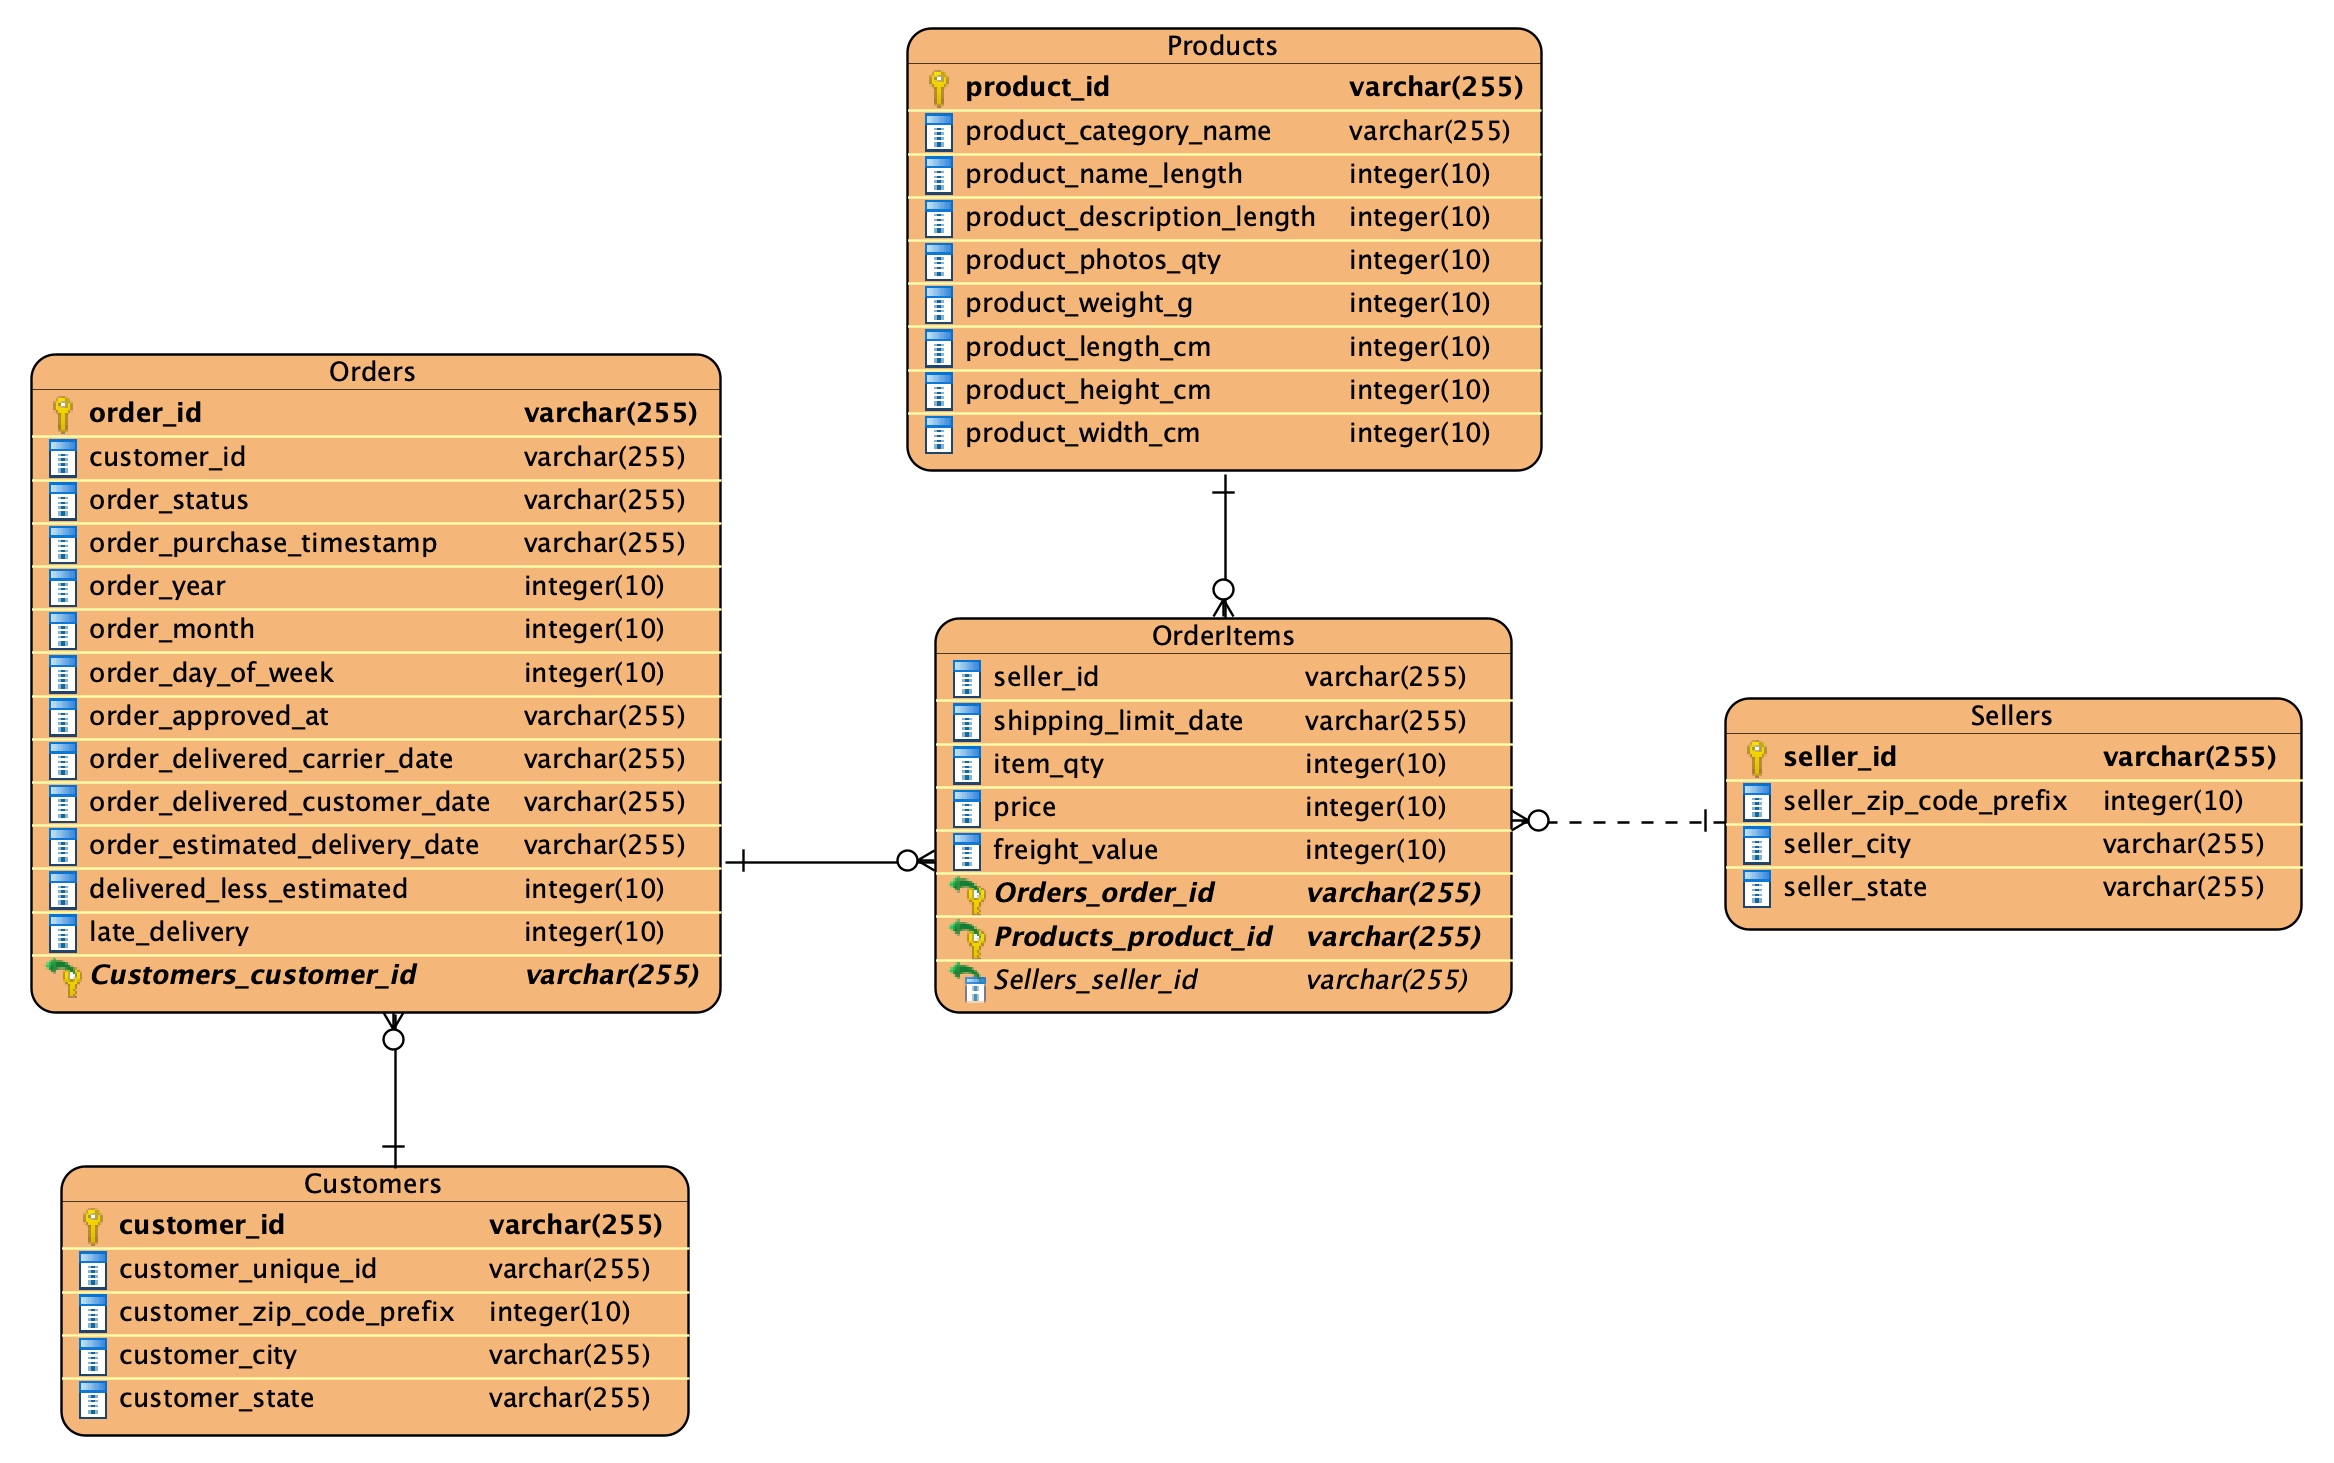

## Question 1.1

**Please answer Question 1.1 in the course (Week 10 -> Case Study -> Part 1).**

Proceed to Part 2 after you complete the question in the course.

---
# Part 2: Exploratory Analysis

## 2.1 Create the database

In [ ]:
# File we need to import, hosted in the SC4x course in edX
customers = 'https://mit-sc4x-sharing.sfo3.cdn.digitaloceanspaces.com/python-ml-case-study/SC4x_Week10_CaseStudy_Data_Customers.csv'
order_items = 'https://mit-sc4x-sharing.sfo3.cdn.digitaloceanspaces.com/python-ml-case-study/SC4x_Week10_CaseStudy_Data_OrderItems.csv'
orders = 'https://mit-sc4x-sharing.sfo3.cdn.digitaloceanspaces.com/python-ml-case-study/SC4x_Week10_CaseStudy_Data_Orders.csv'
products = 'https://mit-sc4x-sharing.sfo3.cdn.digitaloceanspaces.com/python-ml-case-study/SC4x_Week10_CaseStudy_Data_Products.csv'
sellers = 'https://mit-sc4x-sharing.sfo3.cdn.digitaloceanspaces.com/python-ml-case-study/SC4x_Week10_CaseStudy_Data_Sellers.csv'

In [ ]:
# Create the database
db = Database(f"""

    CREATE TABLE Customers AS SELECT * FROM read_csv('{customers}',
        delim = ',',
        header = true,
        types = {{
          'customer_id': 'VARCHAR PRIMARY KEY',
          'customer_unique_id': 'VARCHAR',
          'customer_zip_code_prefix': 'VARCHAR',
          'customer_city': 'VARCHAR',
          'customer_state': 'VARCHAR'
        }});

    CREATE TABLE OrderItems AS SELECT * FROM read_csv('{order_items}',
        delim = ',',
        header = true,
        types = {{
          'order_id': 'VARCHAR PRIMARY KEY',
          'product_id': 'VARCHAR REFERENCES Products(product_id)',
          'seller_id': 'VARCHAR REFERENCES Sellers(seller_id)',
          'shipping_limit_date': 'TIMESTAMP',
          'item_qty': 'FLOAT',
          'price': 'FLOAT',
          'freight_value': 'FLOAT'
        }});

    CREATE TABLE Orders AS SELECT * FROM read_csv('{orders}',
      delim = ',',
      header = true,
      types = {{
        'order_id': 'VARCHAR PRIMARY KEY',
        'customer_id': 'VARCHAR REFERENCES Customers(customer_id)',
        'order_status': 'VARCHAR',
        'order_purchase_timestamp': 'TIMESTAMP',
        'order_year': 'INTEGER',
        'order_month': 'INTEGER',
        'order_day_of_week': 'INTEGER',
        'order_approved_at': 'TIMESTAMP',
        'order_delivered_carrier_date': 'TIMESTAMP',
        'order_delivered_customer_date': 'TIMESTAMP',
        'order_estimated_delivery_date': 'TIMESTAMP',
        'delevered_less_estimated': 'FLOAT',
        'late_delivery': 'INTEGER'
      }});

    CREATE TABLE Products AS SELECT * FROM read_csv('{products}',
      delim = ',',
      header = true,
      types = {{
        'product_id': 'VARCHAR PRIMARY KEY',
        'product_category_name': 'VARCHAR',
        'product_name_lenght': 'INTEGER',
        'product_description_lenght': 'INTEGER',
        'product_photos_qty': 'INTEGER',
        'product_weight_g': 'FLOAT',
        'product_length_cm': 'FLOAT',
        'product_height_cm': 'FLOAT',
        'product_width_cm': 'FLOAT'
      }});

    CREATE TABLE Sellers AS SELECT * FROM read_csv('{sellers}',
      delim = ',',
      header = true,
      types = {{
        'seller_id': 'VARCHAR PRIMARY KEY',
        'seller_zip_code_prefix': 'VARCHAR',
        'seller_city': 'VARCHAR',
        'seller_state': 'VARCHAR'
      }});

""")

**How is the database above working?**

* `Database()` comes from the `scx` package. Let's [look at the source](https://connor-makowski.github.io/scx/scx/database.html).

* The `scx` package is built on [DuckDB](https://duckdb.org/), an in-process RDBMS. The [DuckDB docs](https://duckdb.org/docs/stable/sql/introduction) is useful reference to bookmark.

* `f(""" ... """)` is a [formatted string literal](https://docs.python.org/3/tutorial/inputoutput.html#tut-f-strings) (f-string) allowing us to pass Python expressions with the query as `{ ... }`.

**How is DuckDB different from MySQL?**

*   MySQL is a general-purpose database application that has been around for a long time. It has many features and capabilities for robust database workloads.

*   DuckDB is a newer database that is runs in-process and is built for analytical workloads. It is fast, portable, and simple to administer.

*   Both support the basic SQL statements we focus on in this course: SELECT, FROM, WHERE, etc.

*   There are many differences in terms of capabilities and use cases that are beyond the the scope of this course, such as database administration and ACID (Atomicity, Consistency, Isolation, Durability) compliance: MySQL is fully compliant, DuckDB is partially.

*   There are small differences seen in this course, such as the syntax used for specifying data types and keys when we create tables. In the course, the code for each tool will be given.

*   The [DuckDB](https://duckdb.org/docs/stable/sql/introduction) and [MySQL](https://dev.mysql.com/doc/) documentation are useful references to bookmark.

* If you want to learn more, there are many good online resources, such as the [W3Schools](https://www.w3schools.com/mysql/) and [DataCamp](https://www.datacamp.com/doc/mysql) tutorials for MySQL and the [DataCamp](https://www.datacamp.com/tutorial/building-ai-projects-with-duckdb) tutorial for DuckDB.



In [ ]:
# Show the database schema
db.show_info()

In [ ]:
# Example query
pprint(db.query("""

    SELECT *
    FROM Customers
    LIMIT 3;

"""))

### Question 2.1

**How many rows are there in the OrderItems table?**

*Submit your answer in the course (Week 10 -> Case Study -> Part 2). If you get stuck, the solution is available after you attempt the question.*

In [ ]:
# Query template
pprint(db.query("""

    SQL_HERE

"""))

## 2.2 Extract data from the database

In [ ]:
# Save the output from query() as a new variable
customers_output = db.query("""

    SELECT * FROM Customers;

""")

In [ ]:
# Convert the output into a Pandas DataFrame
customers_df = pd.DataFrame(customers_output)

**Pandas** is a popular library for data analysis and manipulation. There are a number of useful tutorials, books, videos, cheat sheets, and other resources on the [Pandas website here](https://pandas.pydata.org/getting_started.html).

**DataFrames** are a table-like data structure for data in Pandas and other similar libraries. We will work with many of the common features of DataFrames in this case study. If you want to learn more, there are many good online resources, such as the [W3Schools](https://www.w3schools.com/python/pandas/pandas_dataframes.asp) and [DataCamp](https://www.datacamp.com/tutorial/pandas-tutorial-dataframe-python) tutorials and the [Pandas User Guide](https://pandas.pydata.org/docs/user_guide/dsintro.html#dataframe).

There are many other data structures available in Python and Pandas. You can learn more about the [basic data structures in Pandas here](https://pandas.pydata.org/docs/user_guide/dsintro.html).

In [ ]:
# Show information about the DataFrame
customers_df.info()

In [ ]:
# View the first 3 rows as a formatted table
display(customers_df.head(3))

### Question 2.2

**What is the zip code prefix of the second-to-last record?**

*Try to solve this using Python in the code cell below, then submit your answer in the course (Week 10 -> Case Study -> Part 2). If you get stuck, the solution is available after you attempt the question.*

In [ ]:
# What is the zip code prefix of the second-to-last record?
# Hint: You can use the .tail() similar to the .head() function.

In [ ]:
# Solution
display(customers_df.tail(3))

## 2.3 Counting and filtering

In [ ]:
# We can count records within the database using SQL
pprint(db.query("""

    SELECT COUNT(customer_id)
    FROM Customers
    WHERE customer_city = 'sao paulo';

"""))

There are a variety of ways to count records with Python and Pandas as well, such as:
* Filter a DataFrame using the bracket (`[...]`) operator
* .nunique() function
* .query() function (Pandas function similar to what we use for the database)
* .value_counts() function
* and more!

In [ ]:
# Let's filter for a subset of the DataFrame using the [...] syntax
customer_SaoPaulo = customers_df[customers_df["customer_city"] == "sao paulo"]
customer_SaoPaulo.head()

In [ ]:
customer_SaoPaulo.info()

In [ ]:
# We can access the number of entries using shape
customer_SaoPaulo.shape[0]

In [ ]:
# What if we want to check the number of unique customer IDs?
customer_SaoPaulo.customer_id.nunique()

In [ ]:
# Pandas also has a .query() method, which allows us to use a different syntax
customers_df.query("customer_city == 'sao paulo'").shape[0]

In [ ]:
# We can count the number of customers for each city using value_counts()
customers_df.customer_city.value_counts().head()

In [ ]:
# How many cities are there?
customers_df.customer_city.nunique()

Let's create a new DataFrame with the OrderItems table.

In [ ]:
# Create a new DataFrame with the OrderItems table
orderItems_output = db.query("""

    SELECT * FROM OrderItems;

""")
orderItems_df = pd.DataFrame(orderItems_output)

In [ ]:
display(orderItems_df.head())

In [ ]:
orderItems_df.info()

### Question 2.3

**How many *unique* order IDs are there in the OrderItems table?**

*Try to solve this using Python in the code cell below, then submit your answer in the course (Week 10 -> Case Study -> Part 2). If you get stuck, the solution is available after you attempt the question.*

In [ ]:
# How many unique order IDs are there?
# Hint: Try the .nunique() function

## 2.4 Basic calculations

Complete the section 2.3 above first. You will need `orderItems_df` for this section.

Pandas has many useful functions for computing statistics and other calculations with DataFrames, including:

*   `sum()`
*   `mean()`
*   `median()`
*   And many more!

[Here is a useful resource](https://pandas.pydata.org/pandas-docs/stable/user_guide/basics.html#descriptive-statistics) with a list of functions and how to use them.


### Question 2.4

**What is the total item quantity (item_qty) in the OrderItems table?**

*Try to solve this using Python in the code cell below, then submit your answer in the course (Week 10 -> Case Study -> Part 2). If you get stuck, the solution is available after you attempt the question.*

In [ ]:
# What is the total item quantity (item_qty) in the OrderItems table?

## 2.5 Adding a column to a DataFrame

In [ ]:
# We can save values as new variables. Here we'll save the order ID with the greatest number of order items.
orderId_greatestItemQty = orderItems_df.order_id.value_counts().index[0]

In [ ]:
# Display the order_id
orderId_greatestItemQty

In [ ]:
# Let's calculate the total value for this order
# First, we create a subset for the selected order ID
orders_topOrder = orderItems_df[orderItems_df["order_id"] == orderId_greatestItemQty]

In [ ]:
# Now we'll calculate the value for each order item entry and add it as a column
orders_topOrder.insert(6, "line_value", orders_topOrder.item_qty * orders_topOrder.price)

In [ ]:
# Check that the column was added
orders_topOrder.head()

In [ ]:
# Then print out the order total
pprint(f"""The total value of the order {orderId_greatestItemQty} is ${round(orders_topOrder.line_value.sum(),2)}.""")

## 2.5 Grouping, pivot tables, and sorting

In [ ]:
# Calculate the item quantity for each order using pivot_table()
order_qty_ttl = orderItems_df.pivot_table(index=["order_id"],
                       values=["item_qty"],
                       aggfunc="sum")
order_qty_ttl.head()

In [ ]:
# Let's sort that pivot table to see the top 5 orders
order_qty_ttl.sort_values(by="item_qty", ascending=False).head()

In [ ]:
# We can get the same result using the groupby() function
orderItems_df.groupby("order_id").item_qty.sum().sort_values(ascending=False).head()

## 2.6 Descriptive statistics

In [ ]:
# describe() will calculate descriptive statistics using
orderItems_df.loc[:,["item_qty","price","freight_value"]].describe()

## 2.7 Line charts

Let's create a line chart for the number of orders by the order date.

In [ ]:
# First, we need to get the orders table
orders_dates_df = pd.DataFrame(db.query("""

  SELECT order_id, order_purchase_timestamp, order_year, order_month, order_day_of_week
      FROM Orders;

"""))

In [ ]:
# Next, we'll create a new column for the order date (time removed)
orders_dates_df.insert(2, "order_date", orders_dates_df.order_purchase_timestamp)
orders_dates_df.order_date = orders_dates_df.order_date.apply(lambda x: x.date())

Notes:
 * `lambda` functions are small functions that can be useful embedded inside of other functions

In [ ]:
orders_dates_df.info()

In [ ]:
orders_dates_df.head()

In [ ]:
# Calculate the order count for each calendar date using pivot_table()
orders_by_day = orders_dates_df.pivot_table(index=["order_date"],
                       values=["order_id"],
                       aggfunc="count")

In [ ]:
# Now we can use the plotting capabilities in Pandas to create a simple line chart
orders_by_day.plot()

Notes:
* There are a lot of adjustments we can make to the axes, fonts, colors, and other characteristics of figures.
* Here we'll just highlight a few.

In [ ]:
# Let's adjust the axis labels and rotate the x-axis labels so they are more legible
orders_by_day.plot(xlabel="Order Date", rot=45, ylabel="Number of Orders",legend=False)

### Question 2.7

There is a clear spike in orders visible in the plot.

**What is the order quantity on the date with the greatest quantity?**

Hint: One way to solve this is to sort the table used for the plot above and print out the first few dates.

*Try to solve this using Python in the code cell below, then submit your answer in the course (Week 10 -> Case Study -> Part 2). If you get stuck, the solution is available after you attempt the question.*

In [ ]:
# What is the order quantity on the date with the greatest quantity?

## 2.8 Histograms

Histograms are a useful way to visialize the distrubution of numerical features.

For the line charts above, we used the plotting capabilities in Pandas. Here we will use the [Matplotlib library](https://matplotlib.org/) directly (imported as `plt`), which Pandas is built on.

In [ ]:
# Histograms for orders by month and day-of-week
orders_dates_df.loc[:,["order_month"]].hist(bins=12, range=[1, 12], figsize=(6, 4))
plt.xlim(xmin=1, xmax = 12)
orders_dates_df.loc[:,["order_day_of_week"]].hist(bins=7, range=[1, 7], figsize=(6, 4))
plt.xlim(xmin=1, xmax = 7)
plt.show()

In [ ]:
# Historgrams for product dimensions
product_dims_df = pd.DataFrame(db.query("""

  SELECT product_id, product_weight_g, product_length_cm, product_height_cm, product_width_cm
      FROM Products;

"""))
product_dims_df.hist(bins=20, figsize=(12, 8))
plt.show()

---
# Part 3: Data Engineering

## 3.1 Create a new dataset

Please refer to Part 1 for a description of the project scope and data requirements. The dataset we create below extracts the data that we will need the predictive model from the original database.

In [ ]:
# Let's create a new table with the data we will use for ML
ml_full_df = pd.DataFrame(db.query("""

  SELECT Orders.order_id, Products.product_id, Customers.customer_state, OrderItems.item_qty, OrderItems.price, OrderItems.freight_value, Orders.order_month, Orders.order_day_of_week, Products.product_category_name, Products.product_weight_g, Products.product_length_cm * Products.product_height_cm * Products.product_width_cm AS product_vol_cm, Sellers.seller_state, Orders.late_delivery
      FROM Customers, OrderItems, Orders, Sellers, Products
      WHERE Orders.order_id = OrderItems.order_id
        AND Orders.customer_id = Customers.customer_id
        AND OrderItems.seller_id = Sellers.seller_id
        AND OrderItems.product_id = Products.product_id;

"""))

### Question 3.1

**How many columns does the new dataset have?**

*Please submit your answer in the course (Week 10 -> Case Study -> Part 3).*

## 3.2 Cleaning the data

Missing values (e.g., 'nulls') are a common issue with data. They can be the result of a data entry errors or some other issue in the data pipeline.

First, let's identify the number of records with missing values.


In [ ]:
# Identify the number of records with missing values
missing_summary = pd.DataFrame({
    'Column': ml_full_df.columns,
    'Data Type': ml_full_df.dtypes,
    'Missing Count': ml_full_df.isnull().sum().values,
    'Missing Percentage': round((ml_full_df.isnull().sum() / len(ml_full_df)) * 100, 2).values,
    'Non-Missing Count': ml_full_df.count().values
}).set_index('Column')
display(missing_summary)

There are a variety of strategies to handle missing values, includng:
* Dropping the record or column from the dataset
* Imputing numerical values using a statistical value (mean or median)
* Filling categorical values with a placeholder or based on some pattern in the dataset

Each of these strategies has tradeoffs depending on the dataset and the statistical models that will be used. The simplist approach is to remove the records with missing values, but this comes with the cost of losing data which may be valuable (even if incomplete).

Since less than 2% of the records in this dataset have missing values, and most of those are missing the product category which can't be replaced with a statistical value, we will just drop the records with missing values.

If you are interested in learning more about the other approaches, there are a number of tools and resources available, such as the [imputation capabilities in scikit-learn documented here](https://scikit-learn.org/stable/modules/impute.html).

In [ ]:
# Drop rows with missing values
ml_clean_df = ml_full_df.dropna()

In [ ]:
# Check the cleaned DataFrame for missing values
missing_summary = pd.DataFrame({
    'Column': ml_clean_df.columns,
    'Data Type': ml_clean_df.dtypes,
    'Missing Count': ml_clean_df.isnull().sum().values,
    'Missing Percentage': round((ml_clean_df.isnull().sum() / len(ml_clean_df)) * 100, 2).values,
    'Non-Missing Count': ml_clean_df.count().values
}).set_index('Column')
display(missing_summary)

### Question 3.2

**How many rows did we drop when removing records with missing values?**

*Please submit your answer in the course (Week 10 -> Case Study -> Part 3).*

## 3.3 Encode categorical variables

Machine learning algorithms require numerical input, so we need to convert categorical data into a numerical format. This process is known as encoding.

Some tools handle encoding behind the scenes. Here, we will demonstrate two common approaches to encoding using scikit-learn.

Typically, we are concerned with two different types of categorical variables:

* Ordinal: Features where order or ranking matters. In our dataset, the categorical features with ordered values are the month and day of the week. We will use ordinal encoding for these features.
* Nominal: Features that do not have an order/ranking. In our dataset, the categorical features that do not have an ordering are the customer's and seller's state, and the product category. We will use one-hot encoding for these features.

To learn more about encoding categorical features, one resource is the [scikit-learn user guide here](https://scikit-learn.org/stable/modules/preprocessing.html#preprocessing-categorical-features).

First, we will designate the feature types in our dataset.

In [ ]:
# Designate the feature types in our dataset
# We will exclude the ID columns from the modeling process
ordinal_features = ["order_month","order_day_of_week"]
nominal_features = ["customer_state","seller_state","product_category_name"]
numerical_features = ["item_qty", "price","freight_value","product_weight_g","product_vol_cm"]

In [ ]:
# Perform ordinal encoding on the ordinal features
# Note: "order_month" and "order_day_of_week" are currently stored as numbers rather than text (e.g., "Monday"), so we technically don't need to encode these variables. However, we will do so here to provide a template for ordinal encoding.
ml_encoded_df = ml_clean_df.copy()
oe = OrdinalEncoder()
ml_encoded_df[ordinal_features] = oe.fit_transform(ml_encoded_df[ordinal_features])

In [ ]:
# Perform one-hot encoding on the categorical features
ohe = OneHotEncoder(sparse_output=False)
ohe_array = ohe.fit_transform(ml_encoded_df[nominal_features])
ohe_df = pd.DataFrame(ohe_array, columns=ohe.get_feature_names_out(nominal_features))
#ml_encoded_df = pd.concat([ml_encoded_df, ohe_df], axis=1)

## 3.4 Merge the encoded data

In [ ]:
# Now we need to combine the encoded features with the numerical features
X = pd.concat([ml_encoded_df[ordinal_features+numerical_features].reset_index(drop=True), ohe_df], axis=1)

### Question 3.4

**How many columns does the new merged DataFrame (`X`) contain?**

*Please submit your answer in the course (Week 10 -> Case Study -> Part 3).*

## 3.5 Split the data into training and test datasets

In [ ]:
# First, we'll designate the target variable for the model
y = ml_encoded_df["late_delivery"]

In [ ]:
# Next, we'll split the data into training (80%) and test (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=3)

---
# Part 4: Modeling and Performance Metrics

There are many different machine learning algorithms available with scikit-learn and other Python libraries. For this case study, we will just build a single classification model using the Random Forest algorithm.

If you are interested in learning more about the algorithms and other tools available with [scikit-learn, this user guide](https://scikit-learn.org/stable/user_guide.html) is a useful resource.



## 4.1 Train a Random Forest classification model

> Note: The code cell below may take a few minutes to run. This is to be expected. We are training on a large dataset!

In [ ]:
# Train a Random Forest classification model
clf_rf = RandomForestClassifier(n_estimators=100, random_state=3)
clf_rf.fit(X_train, y_train)

In [ ]:
# Test the model on the test dataset
y_pred = clf_rf.predict(X_test)

## 4.2 Evaluating the performance of the model

### 4.2.1 Accuracy

In [ ]:
# We can use accuracy_score() to calculate the proportion of correctly predicted labels
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")

### 4.2.2 AUC Score

In [ ]:
# Get the predicted probabilities for the positive class
y_pred_proba = clf_rf.predict_proba(X_test)[:, 1]

# Calculate the AUC score
auc_score = roc_auc_score(y_test, y_pred_proba)
print(f"AUC Score: {auc_score * 100:.2f}%")

### 4.2.3 Other classification metrics

In [ ]:
# classification_report() provides some common classification metrics
print(classification_report(y_test, y_pred))

Notes:
* In the report above, "0" refers to an order-item delivered on time and "1" refers to an order-time delivered late.

#### Question 4.2.3

**What is the F1 score for predicting on-time delivery?**

*Please submit your answer in the course (Week 10 -> Case Study -> Part 4).*

### 4.2.4 Feature importance

In [ ]:
# With a Random Forest classifier, we can evaluate which features were most important in making predictions
feature_important = pd.DataFrame(clf_rf.feature_importances_)
feature_important.insert(0, "feature", X.columns)
feature_important.columns = ["feature","importance"]
feature_importance_sorted = feature_important.sort_values(by="importance", ascending=True)
plt.barh(feature_importance_sorted.feature, feature_importance_sorted.importance)
plt.ylim(len(X.columns)-10, len(X.columns))
plt.title("Feature Importance with the Random Forest Classifier")
plt.show()

#### Question 4.2.4

**What feature was the most important with the Random Forest classifier?**

*Please submit your answer in the course (Week 10 -> Case Study -> Part 4).*

---
# The end!

Congratulations! You made it to the end of this case study. We hope you found it interesting.

---
# Attribution

This dataset is based on the [Brazilian E-Commerce Public Dataset](https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce) published on Kaggle by Olist and collaborators with the [CC BY-NC-SA 4.0 license](https://creativecommons.org/licenses/by-nc-sa/4.0/).